# Análisis Exploratorio de Datos (AED): dataset *Penguins*

Dataset de pingüinos del archipiélago Palmer (Antártida), incluido en Seaborn. Cada fila es un pingüino, con su especie, la isla donde se midió, el sexo y cuatro medidas morfológicas.

**Índice**
1. Carga de datos y estructura
2. Perfil de las variables categóricas
3. Perfil de las variables numéricas
4. Calidad de los datos: nulos, duplicados y outliers
5. Distribuciones
6. Diferencias entre especies
7. Diseño del muestreo: especie × isla
8. Correlaciones
9. Paradoja de Simpson
10. Dimorfismo sexual
11. Conclusiones y siguientes pasos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.precision", 2)

## 1. Carga de datos y estructura

In [2]:
df = sns.load_dataset("penguins")
print("Filas y columnas:", df.shape)
df.head()

Filas y columnas: (344, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [3]:
# Tipos de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    str    
 1   island             344 non-null    str    
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    str    
dtypes: float64(4), str(3)
memory usage: 18.9 KB


Clasificamos las columnas:
- **Dimensiones (categóricas):** `species`, `island`, `sex`.
- **Métricas (numéricas):** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`.

No hay identificador ni columna temporal: la granularidad es *un pingüino por fila*.

In [4]:
categoricas = ["species", "island", "sex"]
numericas = df.select_dtypes("number").columns.tolist()
numericas

['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

## 2. Perfil de las variables categóricas

In [5]:
for col in categoricas:
    print(f"--- {col} ---")
    print(df[col].value_counts(dropna=False))
    print()

--- species ---
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

--- island ---
island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

--- sex ---
sex
Male      168
Female    165
NaN        11
Name: count, dtype: int64



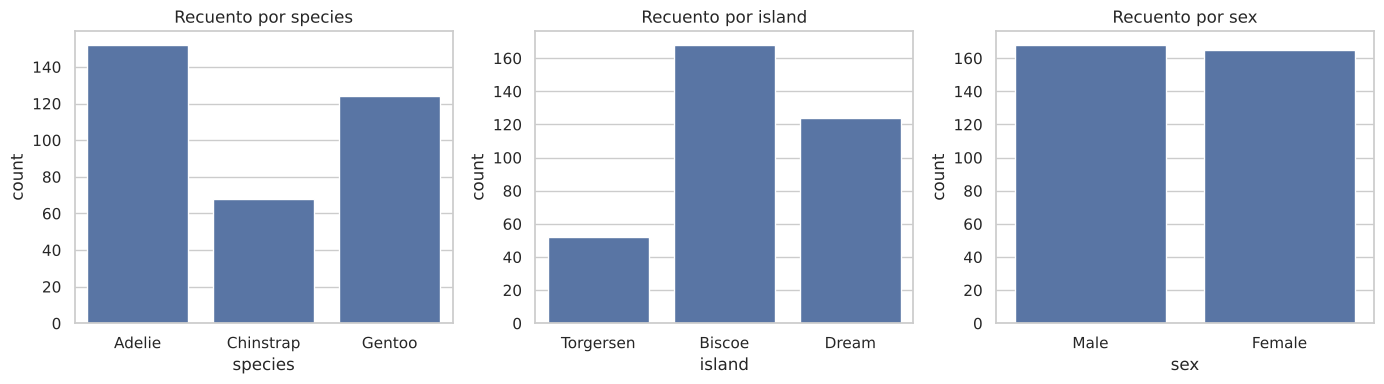

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, categoricas):
    sns.countplot(data=df, x=col, ax=ax)
    ax.set_title(f"Recuento por {col}")
plt.tight_layout()
plt.show()

## 3. Perfil de las variables numéricas

In [7]:
# Estadísticos descriptivos con percentiles adicionales
df[numericas].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
bill_length_mm,342.0,43.92,5.46,32.1,34.04,35.7,39.23,44.45,48.5,51.99,55.51,59.6
bill_depth_mm,342.0,17.15,1.97,13.1,13.44,13.9,15.60,17.30,18.7,20.00,21.10,21.5
flipper_length_mm,342.0,200.92,14.06,172.0,178.00,181.0,190.00,197.00,213.0,225.00,230.00,231.0
body_mass_g,342.0,4201.75,801.95,2700.0,2900.00,3150.0,3550.00,4050.00,4750.0,5650.00,5979.50,6300.0


In [8]:
# Mediana y asimetría (skewness): >0 cola a la derecha, <0 cola a la izquierda
pd.DataFrame({
    "media": df[numericas].mean(),
    "mediana": df[numericas].median(),
    "asimetria": df[numericas].skew(),
})

,media,mediana,asimetria
bill_length_mm,43.92,44.45,0.05
bill_depth_mm,17.15,17.30,-0.14
flipper_length_mm,200.92,197.00,0.35
body_mass_g,4201.75,4050.00,0.47


## 4. Calidad de los datos

### 4.1 Valores nulos

In [9]:
nulos = pd.DataFrame({
    "nulos": df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(1),
})
nulos

,nulos,porcentaje
species,0,0.0
island,0,0.0
bill_length_mm,2,0.6
bill_depth_mm,2,0.6
flipper_length_mm,2,0.6
body_mass_g,2,0.6
sex,11,3.2


In [10]:
# ¿Qué filas tienen algún nulo?
df[df.isna().any(axis=1)]

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
8,Adelie,Torgersen,34.1,18.1,193.0,3475.0,NaN
9,Adelie,Torgersen,42.0,20.2,190.0,4250.0,NaN
10,Adelie,Torgersen,37.8,17.1,186.0,3300.0,NaN
11,Adelie,Torgersen,37.8,17.3,180.0,3700.0,NaN
47,Adelie,Dream,37.5,18.9,179.0,2975.0,NaN
246,Gentoo,Biscoe,44.5,14.3,216.0,4100.0,NaN
286,Gentoo,Biscoe,46.2,14.4,214.0,4650.0,NaN
324,Gentoo,Biscoe,47.3,13.8,216.0,4725.0,NaN
336,Gentoo,Biscoe,44.5,15.7,217.0,4875.0,NaN


Hay dos situaciones distintas:
- **2 filas completamente vacías** en las medidas (solo especie e isla). Se eliminarán.
- **9 filas sin `sex`** pero con todas las medidas. Se pueden conservar o imputar.

In [11]:
filas_vacias = df[numericas].isna().all(axis=1)
print("Filas sin ninguna medida:", filas_vacias.sum())
print("Filas con medidas pero sin sexo:", (df["sex"].isna() & ~filas_vacias).sum())

Filas sin ninguna medida: 2
Filas con medidas pero sin sexo: 9


### 4.2 Duplicados

In [12]:
print("Filas duplicadas:", df.duplicated().sum())

Filas duplicadas: 0


### 4.3 Outliers (regla del 1,5 × IQR)

In [13]:
def contar_outliers(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    return ((serie < q1 - 1.5 * iqr) | (serie > q3 + 1.5 * iqr)).sum()

df[numericas].apply(contar_outliers)

bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64

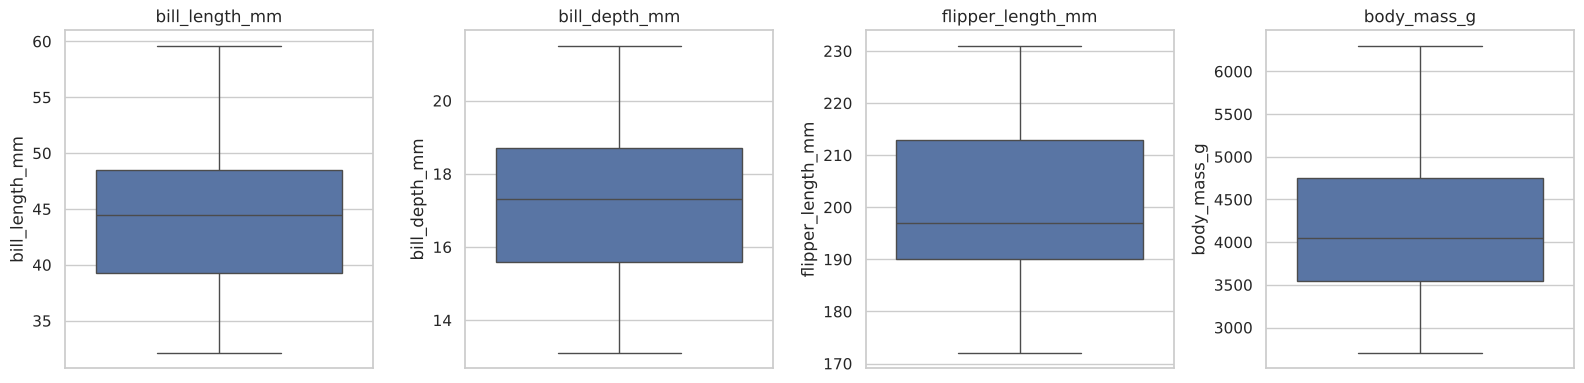

In [14]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(y=df[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

### 4.4 Limpieza

In [15]:
# Eliminamos las 2 filas sin medidas; mantenemos las de sexo desconocido
df_limpio = df.dropna(subset=numericas).copy()
print("Filas tras la limpieza:", len(df_limpio))

Filas tras la limpieza: 342


## 5. Distribuciones

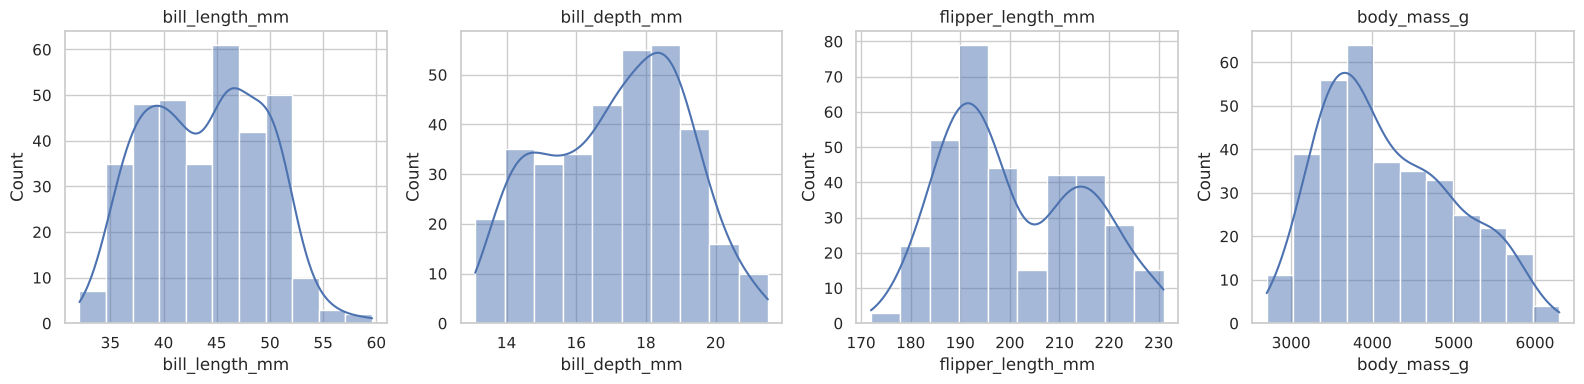

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numericas):
    sns.histplot(df_limpio[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Algunas distribuciones parecen **bimodales** (dos picos). Veamos qué ocurre si las separamos por especie:

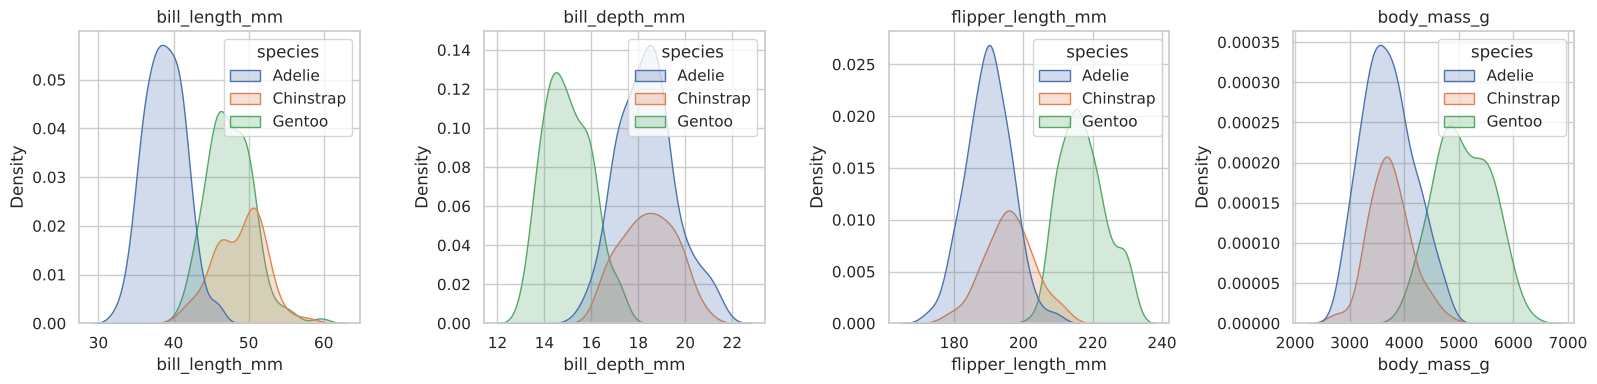

In [17]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numericas):
    sns.kdeplot(data=df_limpio, x=col, hue="species", fill=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Los dos picos corresponden a especies distintas: Gentoo forma un grupo aparte, mayor que Adelie y Chinstrap.

## 6. Diferencias entre especies

In [18]:
df_limpio.groupby("species")[numericas].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
species,,,,
Adelie,38.79,18.35,189.95,3700.66
Chinstrap,48.83,18.42,195.82,3733.09
Gentoo,47.50,14.98,217.19,5076.02


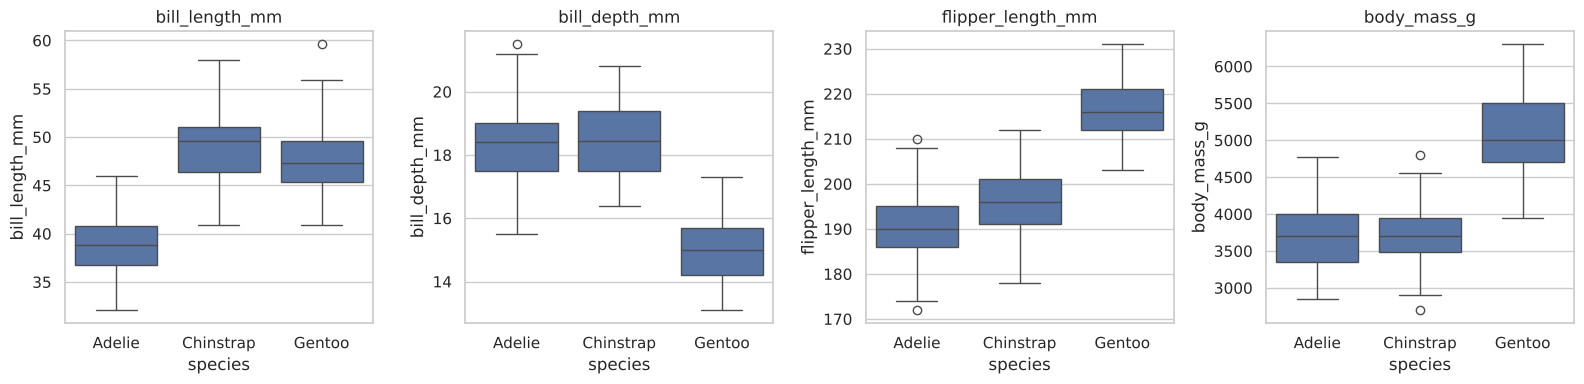

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, numericas):
    sns.boxplot(data=df_limpio, x="species", y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

**ANOVA de un factor**: ¿la masa corporal media es igual en las tres especies?
- H₀: las medias son iguales.
- Si p < 0,05, rechazamos H₀.

In [20]:
grupos = [g["body_mass_g"] for _, g in df_limpio.groupby("species")]
f, p = stats.f_oneway(*grupos)
print(f"F = {f:.1f}, p = {p:.2e}")

F = 343.6, p = 2.89e-82


## 7. Diseño del muestreo: especie × isla

In [21]:
pd.crosstab(df["species"], df["island"], margins=True)

island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,52,152
Chinstrap,0,68,0,68
Gentoo,124,0,0,124
All,168,124,52,344


Chinstrap solo aparece en Dream y Gentoo solo en Biscoe. **Isla y especie están confundidas**: no podemos separar el efecto de la isla del de la especie, salvo para Adelie, que está en las tres islas.

In [22]:
# Único contraste limpio de 'efecto isla': Adelie en las tres islas
adelie = df_limpio[df_limpio["species"] == "Adelie"]
adelie.groupby("island")[numericas].mean()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
island,,,,
Biscoe,38.98,18.37,188.80,3709.66
Dream,38.50,18.25,189.73,3688.39
Torgersen,38.95,18.43,191.20,3706.37


## 8. Correlaciones

In [23]:
corr = df_limpio[numericas].corr()
corr

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.00,-0.24,0.66,0.60
bill_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


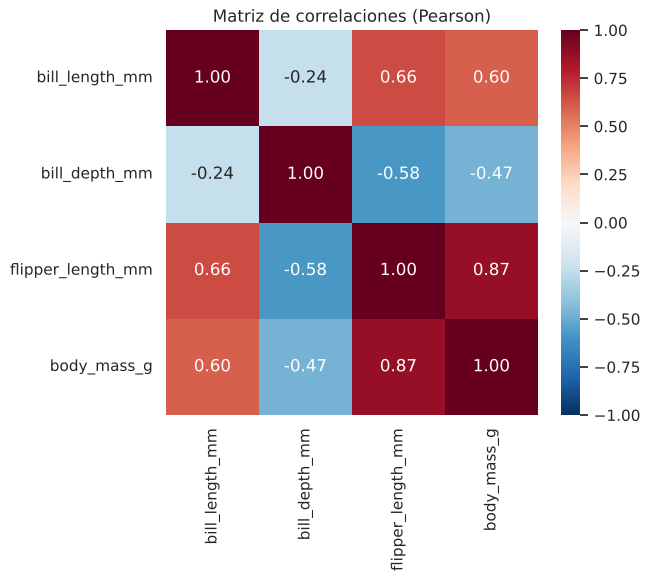

In [24]:
plt.figure(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1)
plt.title("Matriz de correlaciones (Pearson)")
plt.show()

In [25]:
# Pares con correlación fuerte (|r| > 0,7)
pares = corr.where(np.triu(np.ones(corr.shape, dtype=bool), k=1)).stack()
pares[pares.abs() > 0.7]

flipper_length_mm  body_mass_g    0.87
dtype: float64

Aleta y masa tienen r = 0,87: son casi redundantes como predictores. Recuerda que **correlación no implica causalidad**.

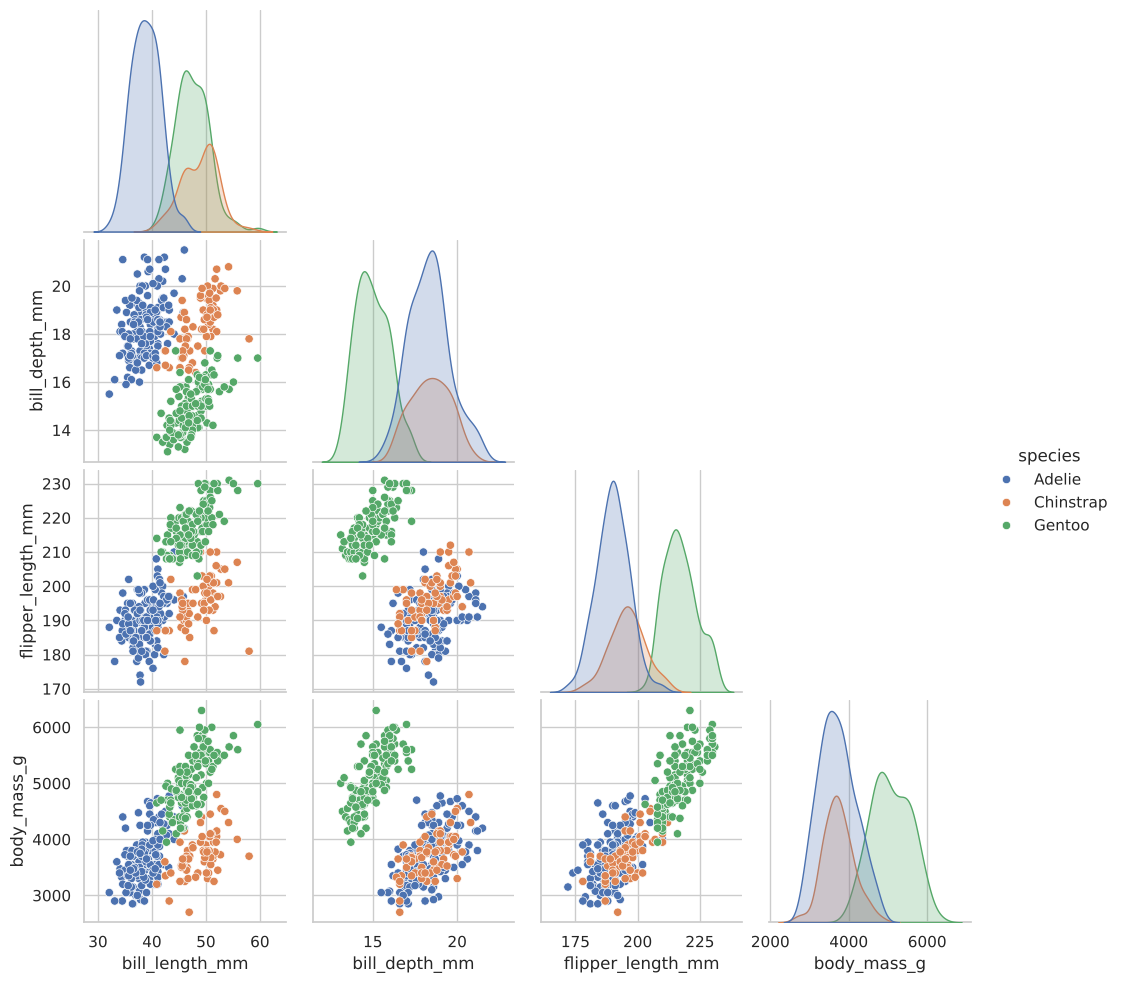

In [26]:
sns.pairplot(df_limpio, vars=numericas, hue="species", corner=True)
plt.show()

## 9. Paradoja de Simpson

Comparamos la correlación entre longitud y profundidad del pico **en el total** y **dentro de cada especie**:

In [27]:
r_total = df_limpio["bill_length_mm"].corr(df_limpio["bill_depth_mm"])
print(f"Correlación global: {r_total:.2f}")

r_especie = df_limpio.groupby("species").apply(
    lambda g: g["bill_length_mm"].corr(g["bill_depth_mm"])
)
print("\nCorrelación por especie:")
print(r_especie.round(2))

Correlación global: -0.24

Correlación por especie:
species
Adelie       0.39
Chinstrap    0.65
Gentoo       0.64
dtype: float64


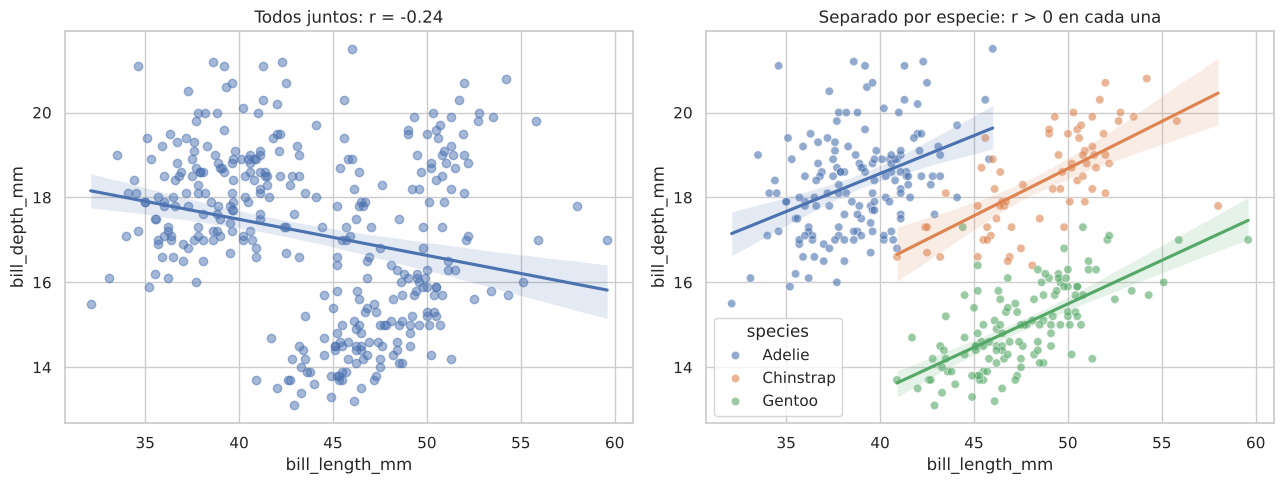

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.regplot(data=df_limpio, x="bill_length_mm", y="bill_depth_mm",
            scatter_kws={"alpha": 0.5}, ax=axes[0])
axes[0].set_title(f"Todos juntos: r = {r_total:.2f}")

sns.scatterplot(data=df_limpio, x="bill_length_mm", y="bill_depth_mm",
                hue="species", alpha=0.6, ax=axes[1])
for especie, g in df_limpio.groupby("species"):
    sns.regplot(data=g, x="bill_length_mm", y="bill_depth_mm",
                scatter=False, ax=axes[1])
axes[1].set_title("Separado por especie: r > 0 en cada una")

plt.tight_layout()
plt.show()

El signo de la correlación **se invierte** al agrupar. Gentoo tiene picos largos pero estrechos, y eso arrastra la tendencia global hacia abajo. Si analizas los datos sin tener en cuenta la especie, llegas a una conclusión equivocada.

## 10. Dimorfismo sexual

In [29]:
masa_sexo = df_limpio.pivot_table(index="species", columns="sex",
                                  values="body_mass_g", aggfunc="mean")
masa_sexo["diferencia"] = masa_sexo["Male"] - masa_sexo["Female"]
masa_sexo.round(0)

sex,Female,Male,diferencia
species,,,
Adelie,3369.0,4043.0,675.0
Chinstrap,3527.0,3939.0,412.0
Gentoo,4680.0,5485.0,805.0


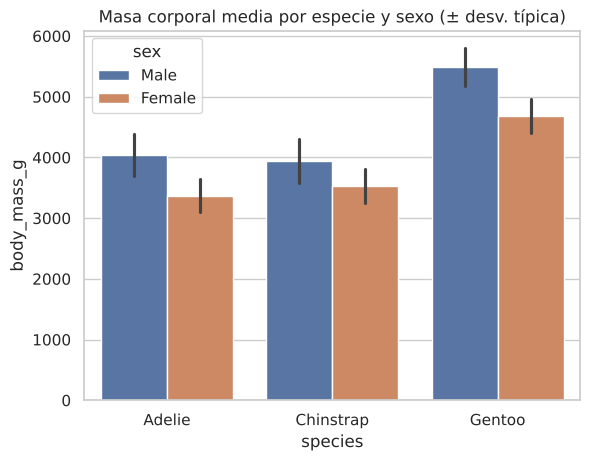

In [30]:
sns.barplot(data=df_limpio.dropna(subset=["sex"]),
            x="species", y="body_mass_g", hue="sex", errorbar="sd")
plt.title("Masa corporal media por especie y sexo (± desv. típica)")
plt.show()

In [31]:
# Prueba t de Welch: ¿machos y hembras difieren en masa dentro de cada especie?
for especie, g in df_limpio.dropna(subset=["sex"]).groupby("species"):
    machos = g.loc[g["sex"] == "Male", "body_mass_g"]
    hembras = g.loc[g["sex"] == "Female", "body_mass_g"]
    t, p = stats.ttest_ind(machos, hembras, equal_var=False)
    print(f"{especie:10s} t = {t:5.2f}  p = {p:.2e}")

Adelie     t = 13.13  p = 6.40e-26
Chinstrap  t =  5.21  p = 2.26e-06
Gentoo     t = 14.76  p = 1.87e-28


## 11. Conclusiones y siguientes pasos

**Conclusiones**
1. Datos de buena calidad: 2 filas vacías, 9 sin sexo, sin duplicados ni outliers.
2. La **especie** explica la mayor parte de la variabilidad. Gentoo es claramente más grande.
3. **Isla y especie están confundidas** por cómo se recogieron los datos.
4. Aleta y masa están muy correlacionadas (r = 0,87).
5. **Paradoja de Simpson** en las medidas del pico: hay que analizar por grupos.
6. Los machos pesan más que las hembras en las tres especies.

**Siguientes pasos propuestos**
- Clasificar la especie a partir de las medidas (por ejemplo, con k-NN o un árbol de decisión).
- Imputar el sexo de las 9 filas incompletas con regresión logística.
- Modelar la masa corporal con regresión lineal (aleta + especie + sexo).